# Lexical dispersion

In [1]:
import polars as pl
import polars_corpus as plc

import matplotlib.pyplot as plt

In [2]:
pl.Config.set_tbl_rows(20)

polars.config.Config

In [4]:
amalgum = pl.read_parquet("../../examples/amalgum.parquet")

- `range` : number of files the word occurs in
- `range%` : the range as a percentage of the files in the corpus
- `sd` : standard deviation of the per-file frequencies $Y_i$:
  $$S=\sqrt{\frac{1}{k}\sum_{i=1}^k(Y_i-\bar Y)^2}$$
- `cv` : coefficient of variation, sd over the mean
   $$CV=\frac{S}{\bar Y}$$
- `cv%` : the coefficient of variation as a percentage
   $$CV\%=\frac{CV}{\sqrt{\textrm{no.\ of corpus parts}}}$$
- `d` : Julliand's $D$:
  $$D=1-\sqrt{\frac{\frac{1}{k-1}\sum_{i=1}^k(Y_i-\bar Y)^2}{k\bar Y^2}}$$

  $$D=1-\sqrt{\frac{\frac{1}{k-1}\sum_i=1^k(Y_i-\bar Y)^2}{k\bar Y^2}$$


- `da` : Burch's DA, from the average difference between pairs of files
- `dp` : Gries's DP, how far the word's spread over the files falls from the corpus's own

In [5]:
disp = plc.dispersion(amalgum, "token", method=['range','range%','sd','cv','cv%','d','da','dp'], min_freq=200)

In [7]:
disp.sort(by='DA', descending=True).head(10)

token,freq,range,range%,sd,cv,cv%,D,DA,DP
str,u32,u32,f64,f64,f64,f64,f64,f64,f64
""".""",165368,4682,100.0,0.013077,0.30654,30.653974,0.99552,0.837177,0.116757
""",""",192424,4679,99.935925,0.017025,0.348879,34.887901,0.994901,0.809651,0.131696
"""and""",95116,4680,99.957283,0.009024,0.368365,36.8365,0.994616,0.794725,0.143495
"""the""",182501,4682,100.0,0.017799,0.377445,37.744523,0.994483,0.790473,0.144943
"""to""",84596,4676,99.87185,0.009071,0.405802,40.580158,0.994069,0.772445,0.159849
"""a""",67458,4679,99.935925,0.007656,0.436592,43.659229,0.993619,0.760671,0.164757
"""in""",63088,4680,99.957283,0.007743,0.465816,46.581574,0.993192,0.74538,0.176706
"""of""",100394,4682,100.0,0.012063,0.460546,46.054571,0.993269,0.744825,0.180839
"""for""",27966,4568,97.565143,0.004493,0.605495,60.549457,0.99115,0.669073,0.229156


In [8]:
disp.sort(by='DA', descending=False).head(10)


token,freq,range,range%,sd,cv,cv%,D,DA,DP
str,u32,u32,f64,f64,f64,f64,f64,f64,f64
"""Pasha""",248,21,0.448526,0.001156,21.867714,2186.771388,0.68038,0.001711,0.994089
"""Brian""",224,38,0.811619,0.001208,24.23728,2423.727963,0.645746,0.002313,0.991898
"""que""",240,31,0.66211,0.001193,17.124353,1712.435332,0.749709,0.003115,0.993644
"""Nicholas""",264,62,1.32422,0.001289,21.742172,2174.217215,0.682215,0.003962,0.985128
"""¥""",252,30,0.640752,0.000713,14.724423,1472.442343,0.784787,0.003998,0.99141
"""Khan""",394,62,1.32422,0.001722,16.644294,1664.42939,0.756726,0.004304,0.986216
"""pet""",386,60,1.281504,0.001537,14.535831,1453.583061,0.787543,0.00451,0.986497
"""Trump""",248,41,0.875694,0.000994,13.599398,1359.939838,0.80123,0.004854,0.991969
"""apartment""",215,72,1.537804,0.000924,14.733621,1473.362143,0.784652,0.005755,0.983257


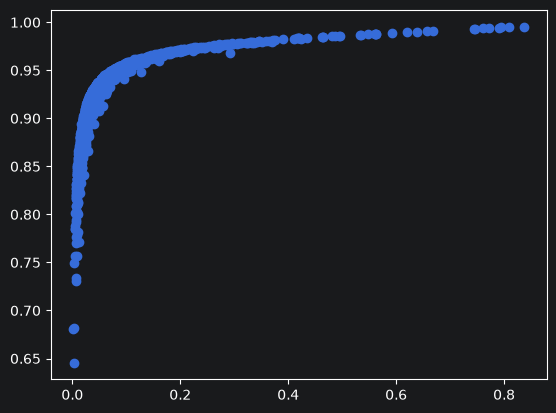

In [9]:
plt.scatter(disp['DA'], disp['D'])

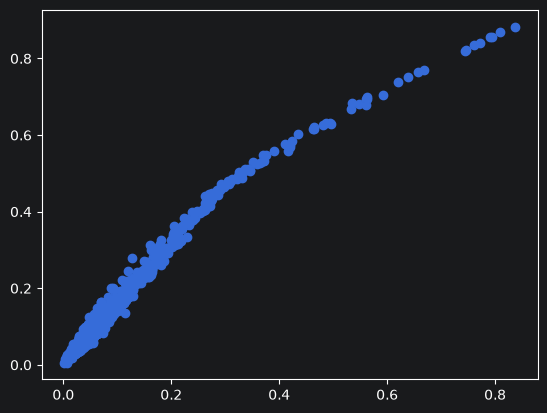

In [10]:
plt.scatter(disp['DA'], 1-disp['DP'])

In [20]:
disp.filter(pl.col('freq')==200)

token,freq,range,range%,sd,cv,cv%,D,DA,DP
str,u32,u32,f64,f64,f64,f64,f64,f64,f64
"""college""",200,130,2.776591,0.000409,7.32194,732.194017,0.892982,0.017937,0.971183
"""i""",200,96,2.050406,0.000622,12.034195,1203.419469,0.824107,0.011576,0.977492
"""stores""",200,138,2.947458,0.000398,7.88042,788.042044,0.884819,0.018667,0.965352
"""Kingdom""",200,151,3.225117,0.000332,6.622056,662.205639,0.903212,0.022912,0.963464
"""B""",200,95,2.029047,0.000428,8.836675,883.667455,0.870843,0.012454,0.97692
"""device""",200,81,1.73003,0.000631,11.143775,1114.377528,0.837122,0.009338,0.982761


# 

<Axes: xlabel='index'>

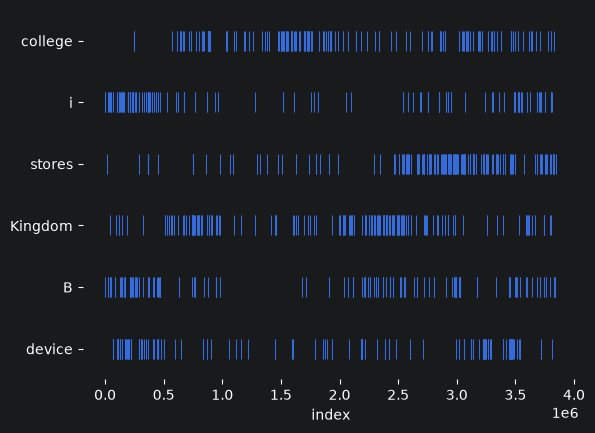

In [21]:
plc.barcode_plot(amalgum, "token", ['college','i','stores','Kingdom','B','device'])


([], [])

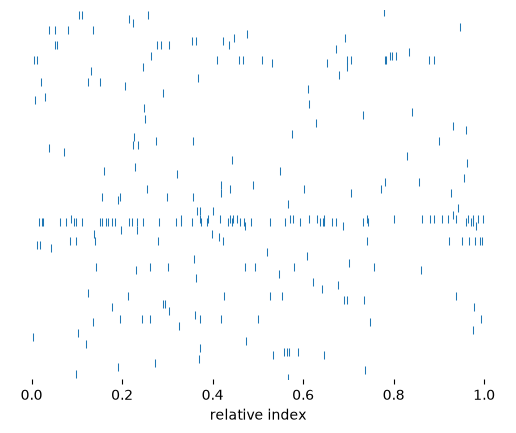

In [48]:
plc.dispersion_plot(brown, "token", 'shall', relative=True, size=30)
plt.yticks([])



<Axes: xlabel='index'>

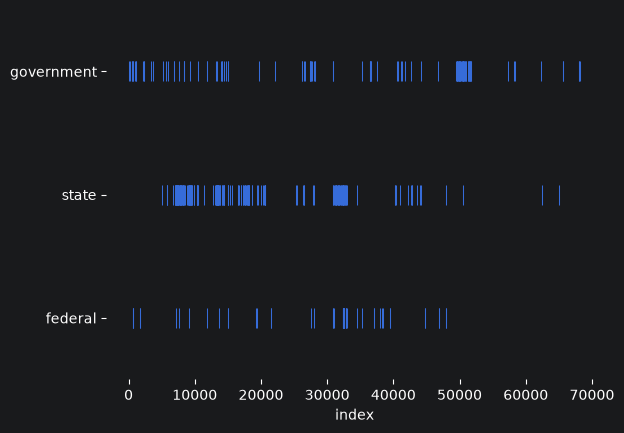

In [13]:
plc.barcode_plot(brown.filter(pl.col('category')=='government'),
                 pl.col("token").str.to_lowercase(),
                 ['government','state','federal',]
                 )
